# 🚗 Used Cars Price Prediction

> **Goal:** Predict the price of used cars using regression models based on vehicle features such as brand, mileage, engine specs, and more.

---

## 📋 Table of Contents

1. [Libraries & Settings](#1-libraries--settings)
2. [Load Data](#2-load-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Cleaning](#4-data-cleaning)
5. [Feature Engineering](#5-feature-engineering)
6. [Visualization](#6-visualization)
7. [Preprocessing & Encoding](#7-preprocessing--encoding)
8. [Model Training & Comparison](#8-model-training--comparison)
9. [Model Evaluation](#9-model-evaluation)
10. [Final Results](#10-final-results)


## 1. Libraries & Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Load Data

In [2]:
df = pd.read_csv('used_cars.csv')
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


## 3. Exploratory Data Analysis

### 3.1 Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


### 3.2 Statistical Summary

In [4]:
df.describe(include='all')

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,188533.000000,188533,188533,188533.000000,188533.000000,183450,188533,188533,188533,188533,186081,167114,1.885330e+05
unique,NaN,57,1897,NaN,NaN,7,1117,52,319,156,2,1,NaN
top,NaN,Ford,F-150 XLT,NaN,NaN,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,NaN
freq,NaN,23088,2945,NaN,NaN,165940,3462,49904,48658,107674,144514,167114,NaN
mean,94266.000000,NaN,NaN,2015.829998,65705.295174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.387802e+04
std,54424.933488,NaN,NaN,5.660967,49798.158076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.881952e+04
min,0.000000,NaN,NaN,1974.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+03
25%,47133.000000,NaN,NaN,2013.000000,24115.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+04
50%,94266.000000,NaN,NaN,2017.000000,57785.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.082500e+04
75%,141399.000000,NaN,NaN,2020.000000,95400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.990000e+04


### 3.3 Categorical Value Counts

In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f'\n--- {col} ---')
        print(df[col].value_counts())


--- brand ---
brand
Ford             23088
Mercedes-Benz    19172
BMW              17028
Chevrolet        16335
Audi             10887
Porsche          10612
Land              9525
Toyota            8850
Lexus             8643
Jeep              6474
Cadillac          4674
RAM               4249
Nissan            3930
Tesla             3738
INFINITI          3276
GMC               3215
Dodge             3133
Mazda             2719
Kia               2497
Lincoln           2423
Subaru            2381
Acura             2282
Honda             2101
Hyundai           2045
Volkswagen        1765
Jaguar            1319
Bentley           1155
MINI              1064
Genesis            969
Buick              940
Maserati           939
Lamborghini        809
Chrysler           727
Volvo              723
Alfa               682
Rivian             590
Rolls-Royce        561
Mitsubishi         551
Pontiac            538
Hummer             520
Ferrari            359
McLaren            243
Aston        

### 3.4 Missing Values

In [6]:
df.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

### 3.5 Duplicate Rows

In [7]:
df.duplicated().sum()

np.int64(0)

## 4. Data Cleaning

### 4.1 Drop Unnecessary Columns

In [8]:
df.drop(columns=['id', 'clean_title'], inplace=True)

### 4.2 Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

### 4.3 Fill Missing Values

In [ ]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident']  = df['accident'].fillna(df['accident'].mode()[0])


df['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], 'Gasoline')


df.isna().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
price           0
dtype: int64

### 4.4 Encode Accident Column

In [11]:
df['accident'] = df['accident'].apply(lambda x: 0 if x == 'None reported' else 1)

### 4.5 Log Transform Target (Price)

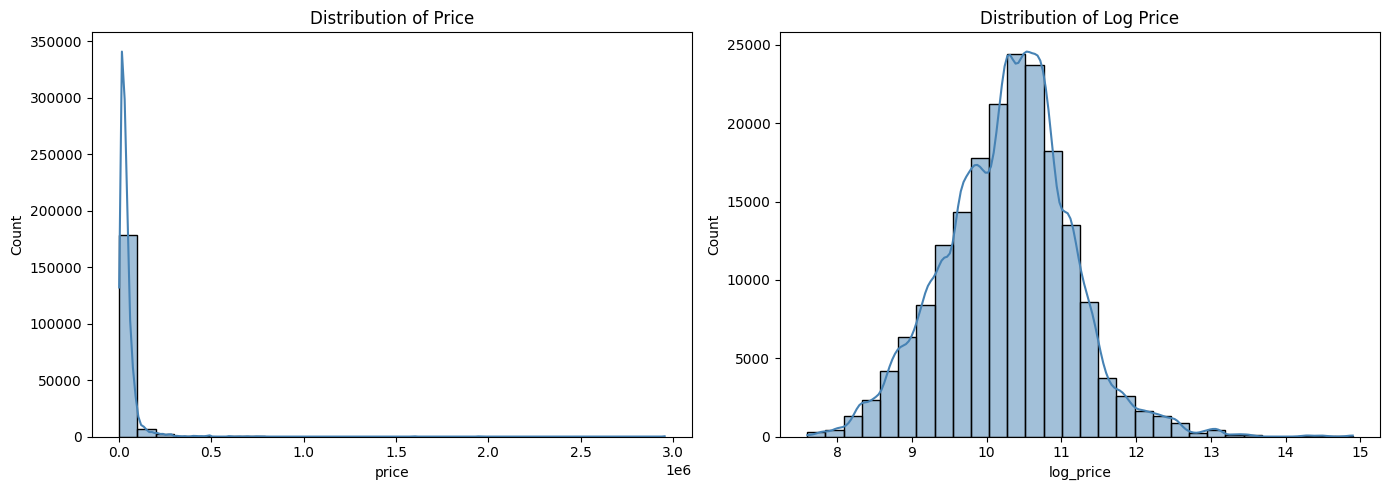

In [12]:
df['log_price'] = np.log(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Price')

sns.histplot(df['log_price'], bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Log Price')

plt.tight_layout()
plt.show()

## 5. Feature Engineering

### 5.1 Engine Features

In [ ]:

df['horsepower']  = df['engine'].str.extract(r'(\d+\.?\d*)\s*HP', flags=re.IGNORECASE).astype(float)
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L(?=\s|$)|Liter)', flags=re.IGNORECASE).astype(float)
df['num_cylinders'] = df['engine'].str.extract(r'[VILWH](\d+)', flags=re.IGNORECASE).astype(float)
df['valve_count'] = df['engine'].str.extract(r'(\d+)V\b').astype(float)


df['is_turbo']        = df['engine'].str.contains('Turbo',        case=False, na=False).astype(int)
df['is_twin_turbo']   = df['engine'].str.contains('Twin Turbo',   case=False, na=False).astype(int)
df['is_supercharged'] = df['engine'].str.contains('Supercharged', case=False, na=False).astype(int)
df['is_electric']     = df['engine'].str.contains('Electric',     case=False, na=False).astype(int)
df['is_diesel']       = df['engine'].str.contains('Diesel',       case=False, na=False).astype(int)
df['is_dohc']         = df['engine'].str.contains('DOHC',         case=False, na=False).astype(int)
df['is_ohv']          = df['engine'].str.contains('OHV',          case=False, na=False).astype(int)


df.loc[df['is_electric'] == 1, ['horsepower', 'engine_size', 'num_cylinders', 'valve_count']] = 0


for col in ['horsepower', 'engine_size', 'num_cylinders', 'valve_count']:
    df[col] = df[col].fillna(df[col].median())


df['hp_per_liter']    = (df['horsepower'] / df['engine_size'].replace(0, np.nan)).fillna(0)
df['hp_per_cylinder'] = (df['horsepower'] / df['num_cylinders'].replace(0, np.nan)).fillna(0)

df.drop(columns=['engine'], inplace=True)
print('Engine features extracted successfully')
print(df[['horsepower','engine_size','num_cylinders','valve_count']].isna().sum())

Engine features extracted successfully
horsepower       0
engine_size      0
num_cylinders    0
valve_count      0
dtype: int64


### 5.2 Car Age & Era

In [14]:
current_year = 2025
df['car_age'] = current_year - df['model_year']

def classify_era(year):
    if year >= 2020:   return 'Modern'
    elif year >= 2015: return 'Recent'
    elif year >= 2010: return 'Mid'
    elif year >= 2000: return 'Old'
    else:              return 'Classic'

df['car_era'] = df['model_year'].apply(classify_era)
df.drop(columns=['model_year'], inplace=True)

### 5.3 Mileage per Year

In [15]:
df['milage_per_year'] = df['milage'] / df['car_age']

### 5.4 Group Rare Colors

In [16]:
top_colors_ext = df['ext_col'].value_counts().nlargest(10).index
df['ext_col'] = df['ext_col'].apply(lambda x: x if x in top_colors_ext else 'other')

top_colors_int = df['int_col'].value_counts().nlargest(10).index
df['int_col'] = df['int_col'].apply(lambda x: x if x in top_colors_int else 'other')

### 5.5 Remove Post-Engineering Duplicates

In [17]:
df.drop_duplicates(subset=['brand', 'model', 'milage', 'price'], inplace=True)
print(f'Dataset shape after cleaning: {df.shape}')

Dataset shape after cleaning: (185522, 26)


## 6. Visualization

### 6.1 Correlation Heatmap

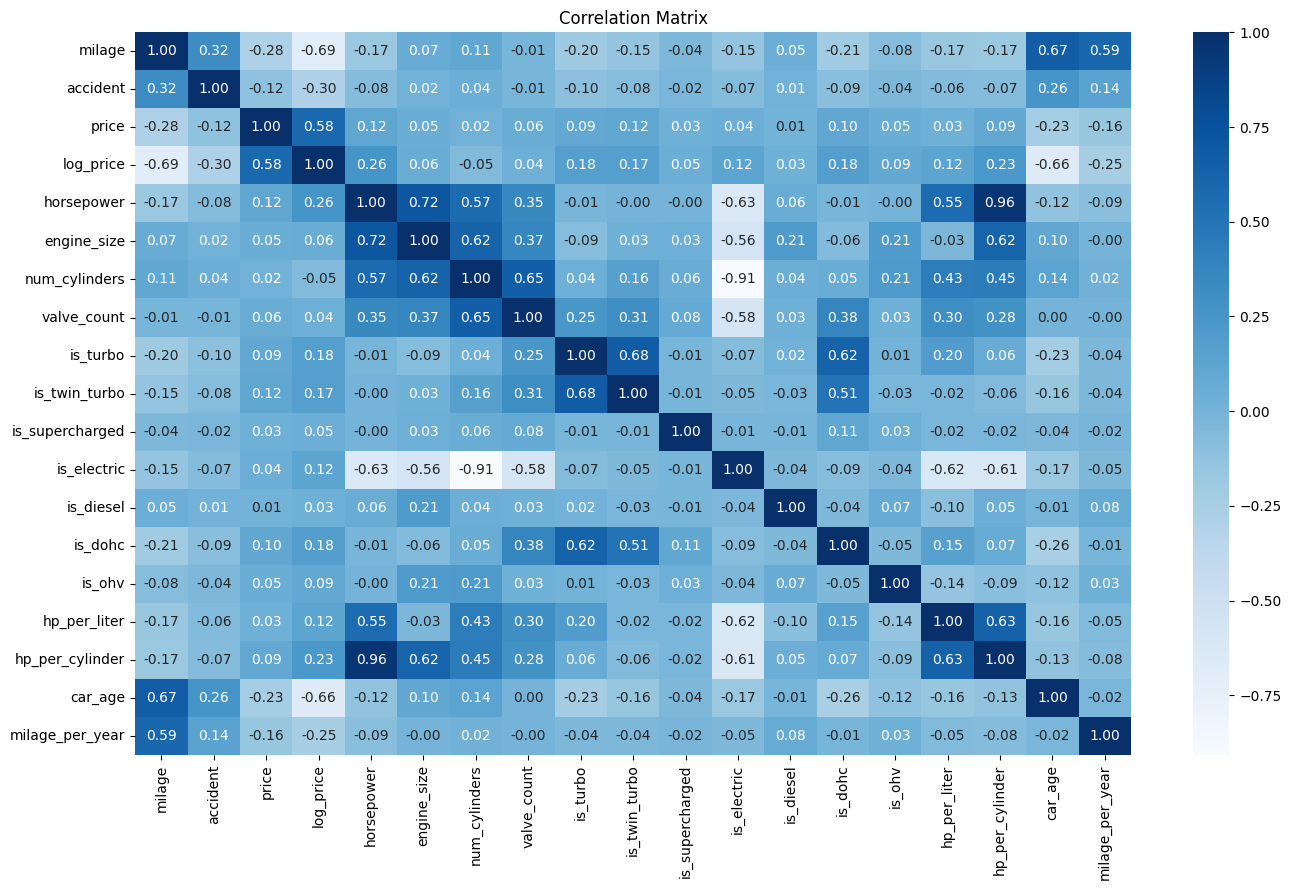

In [18]:
plt.figure(figsize=(14, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 6.2 Numeric Features vs Price

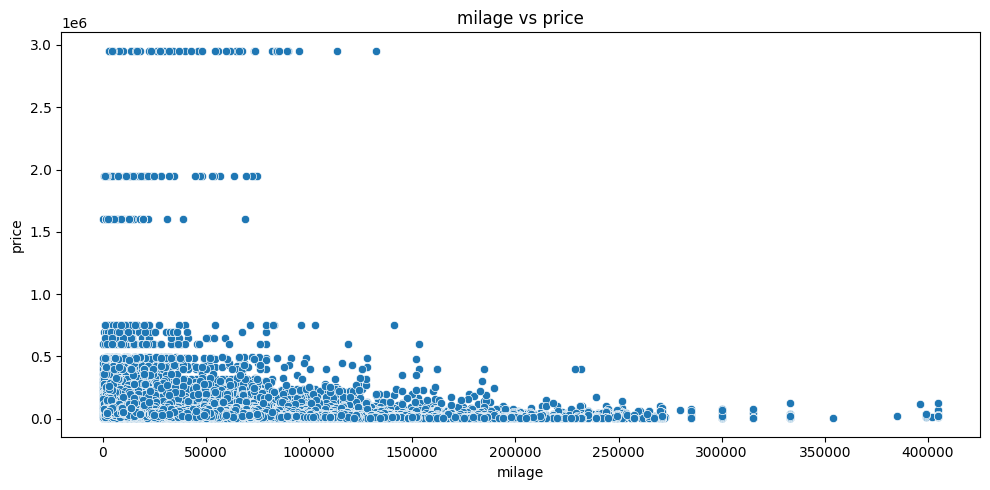

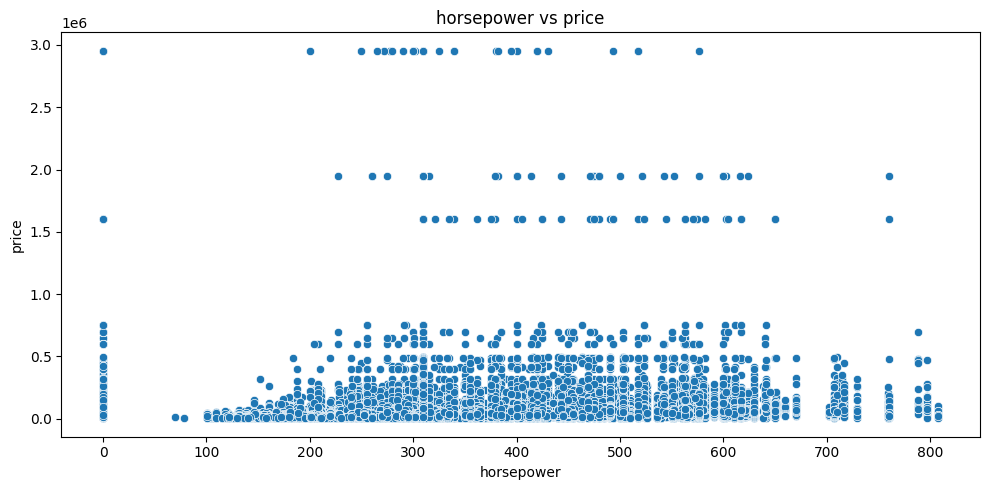

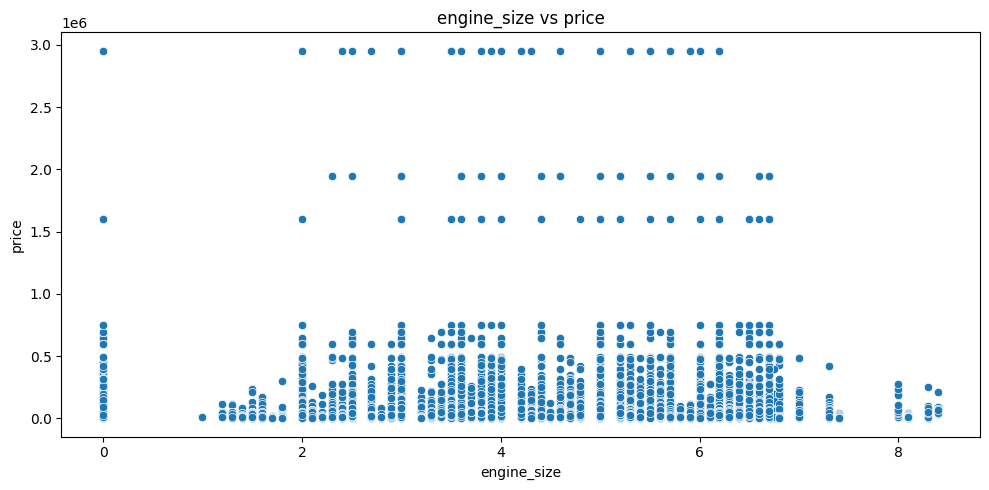

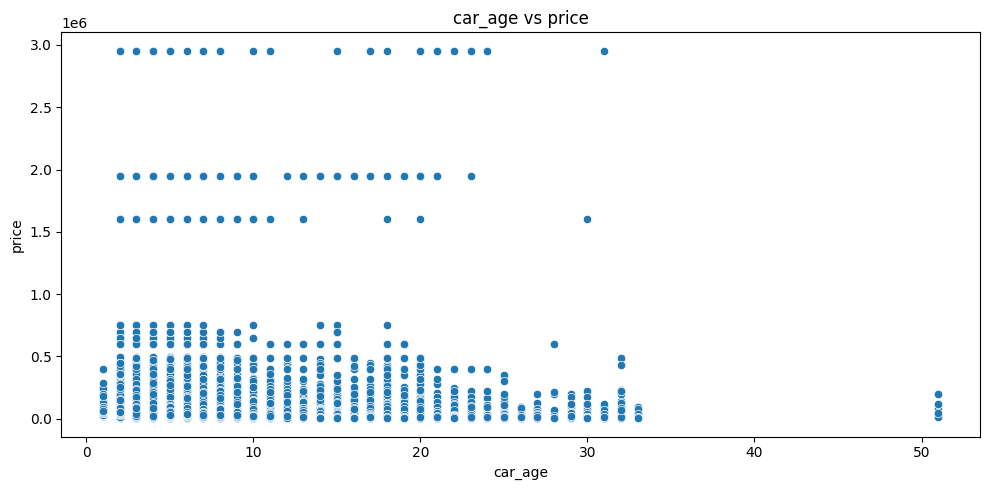

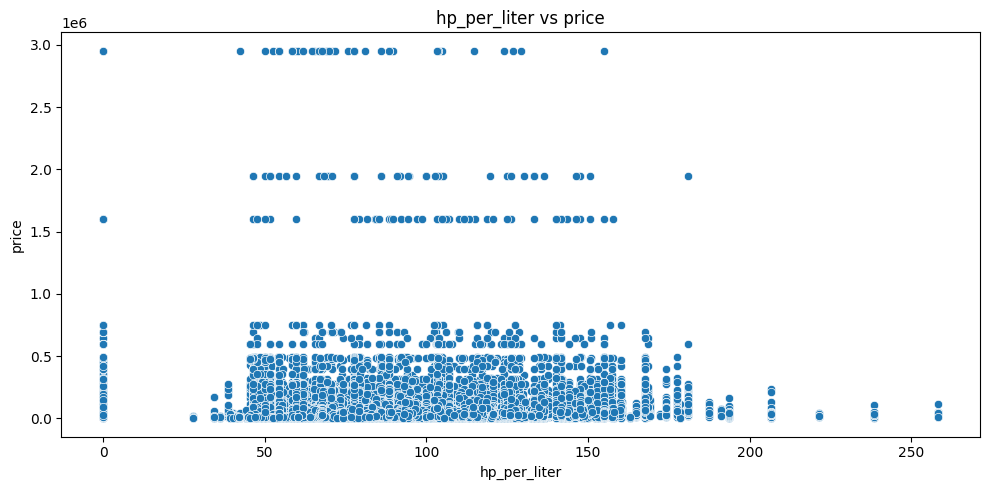

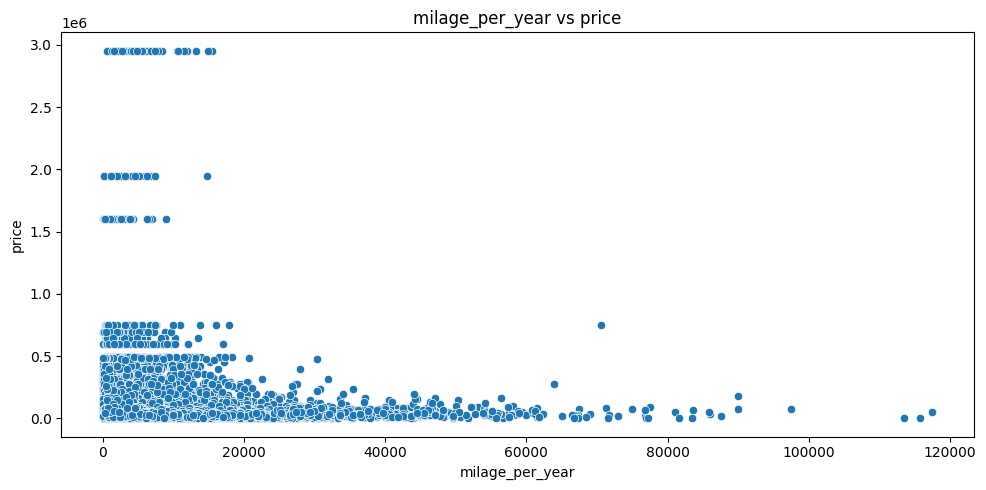

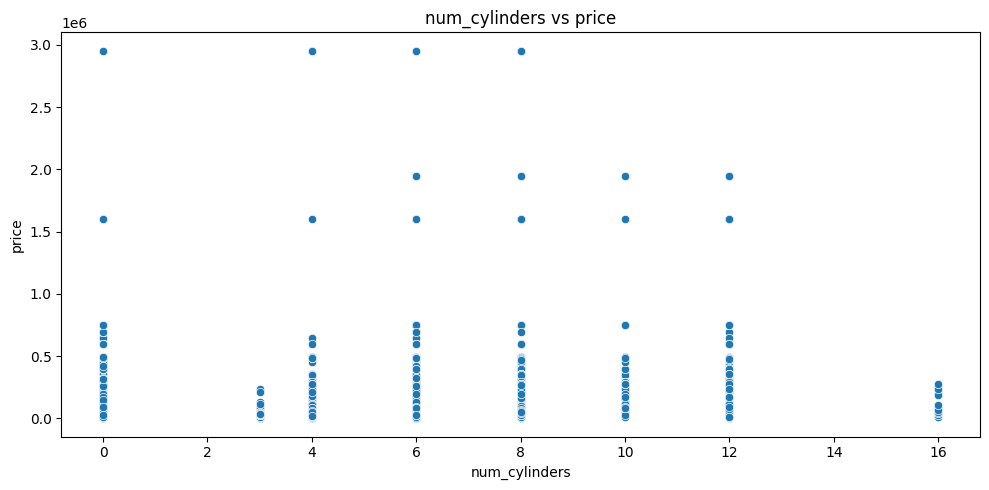

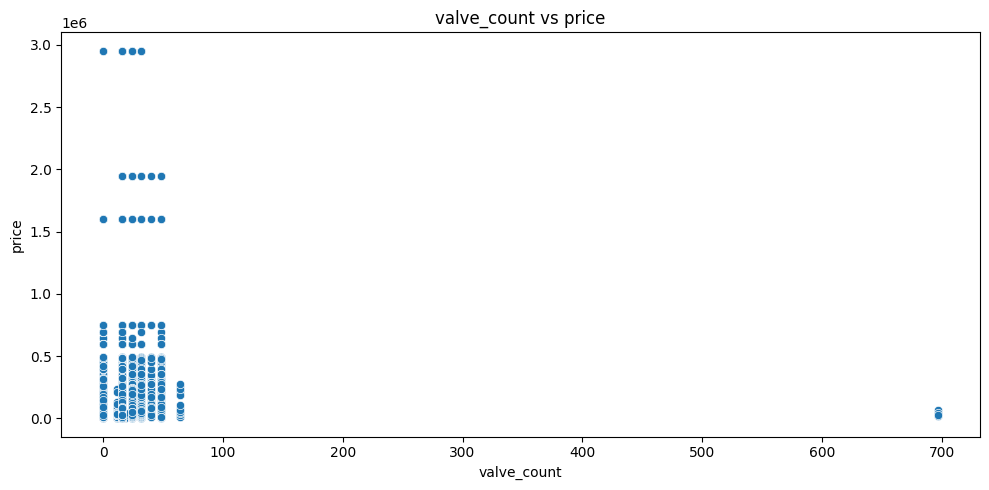

In [33]:
features = ['milage', 'horsepower', 'engine_size', 'car_age', 'hp_per_liter', 'milage_per_year','num_cylinders','valve_count']
for col in features:
    plt.figure(figsize=(10,5))
    sns.scatterplot(x=df[col],y=df['price'],palette='Blues')
    plt.title(f'{col} vs price')
    plt.tight_layout()
    plt.show()


### 6.3 Top 10 Brands by Average Price

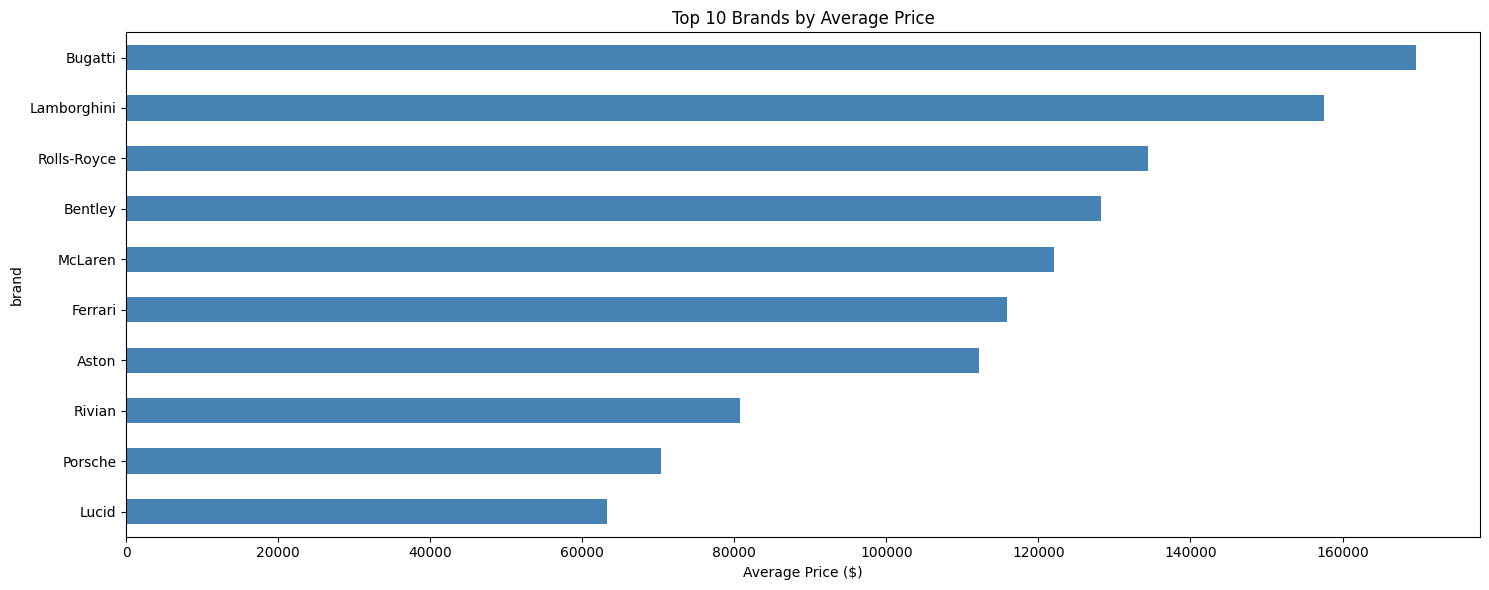

In [20]:
plt.figure(figsize=(15, 6))
top10 = df.groupby('brand')['price'].mean().nlargest(10).sort_values()
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Brands by Average Price')
plt.xlabel('Average Price ($)')
plt.tight_layout()
plt.show()

### 6.4 Categorical Features vs Price

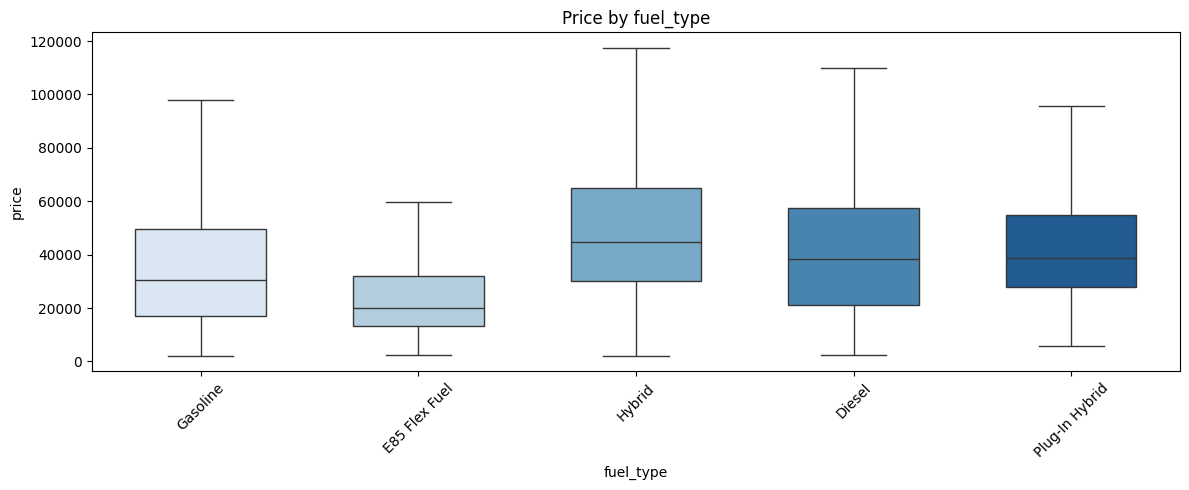

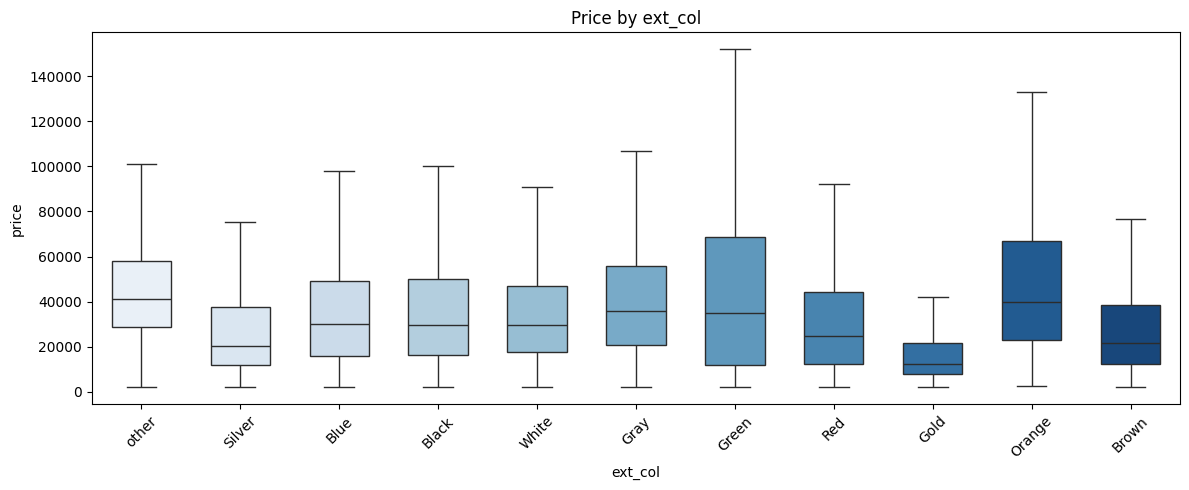

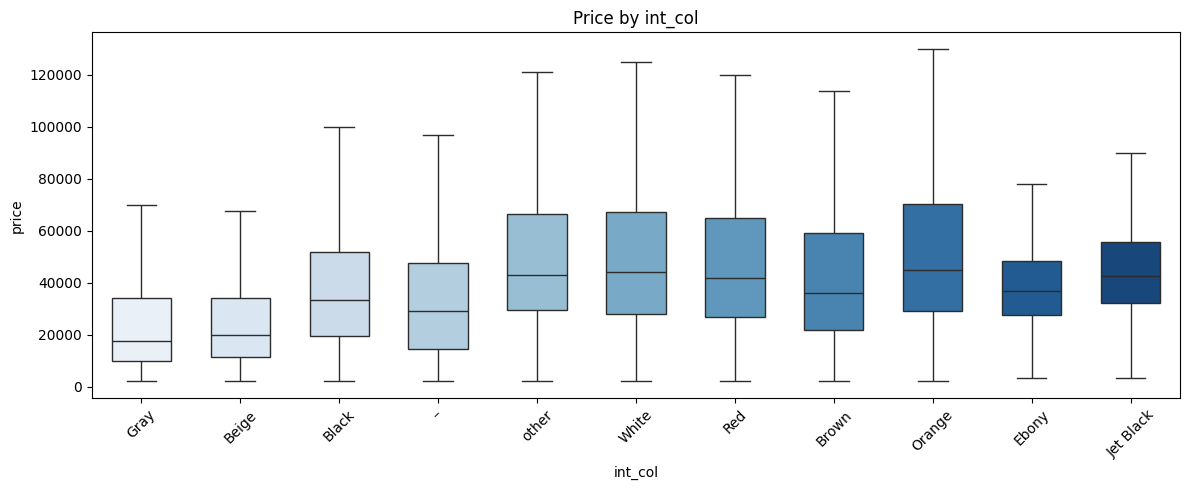

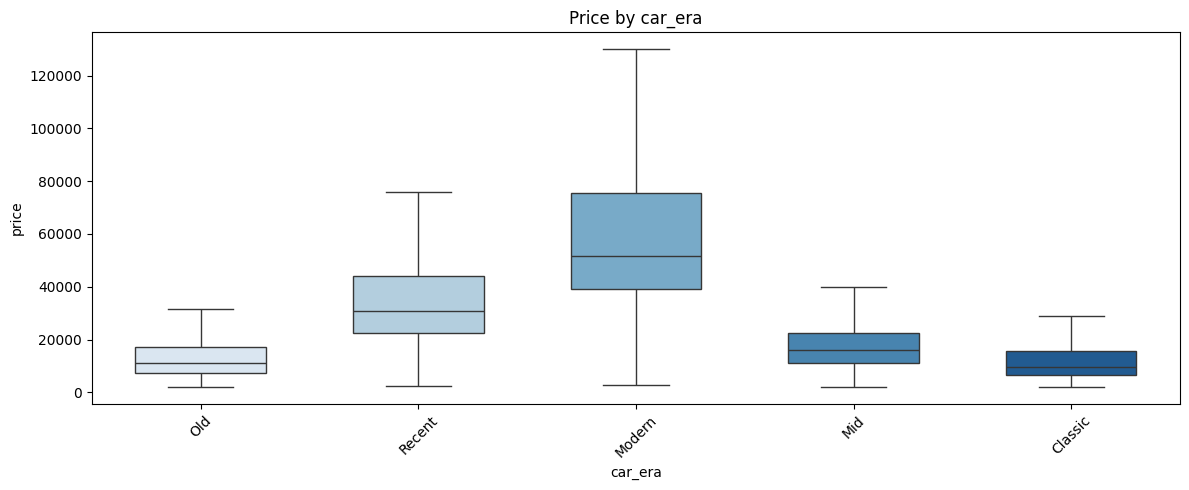

In [21]:
categorical = ['fuel_type', 'ext_col', 'int_col', 'car_era']
for col in categorical:
    plt.figure(figsize=(12, 5))
    sns.boxplot(x=df[col], y=df['price'], palette='Blues', showfliers=False, width=0.6)
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 6.5 Binary Features vs Log Price

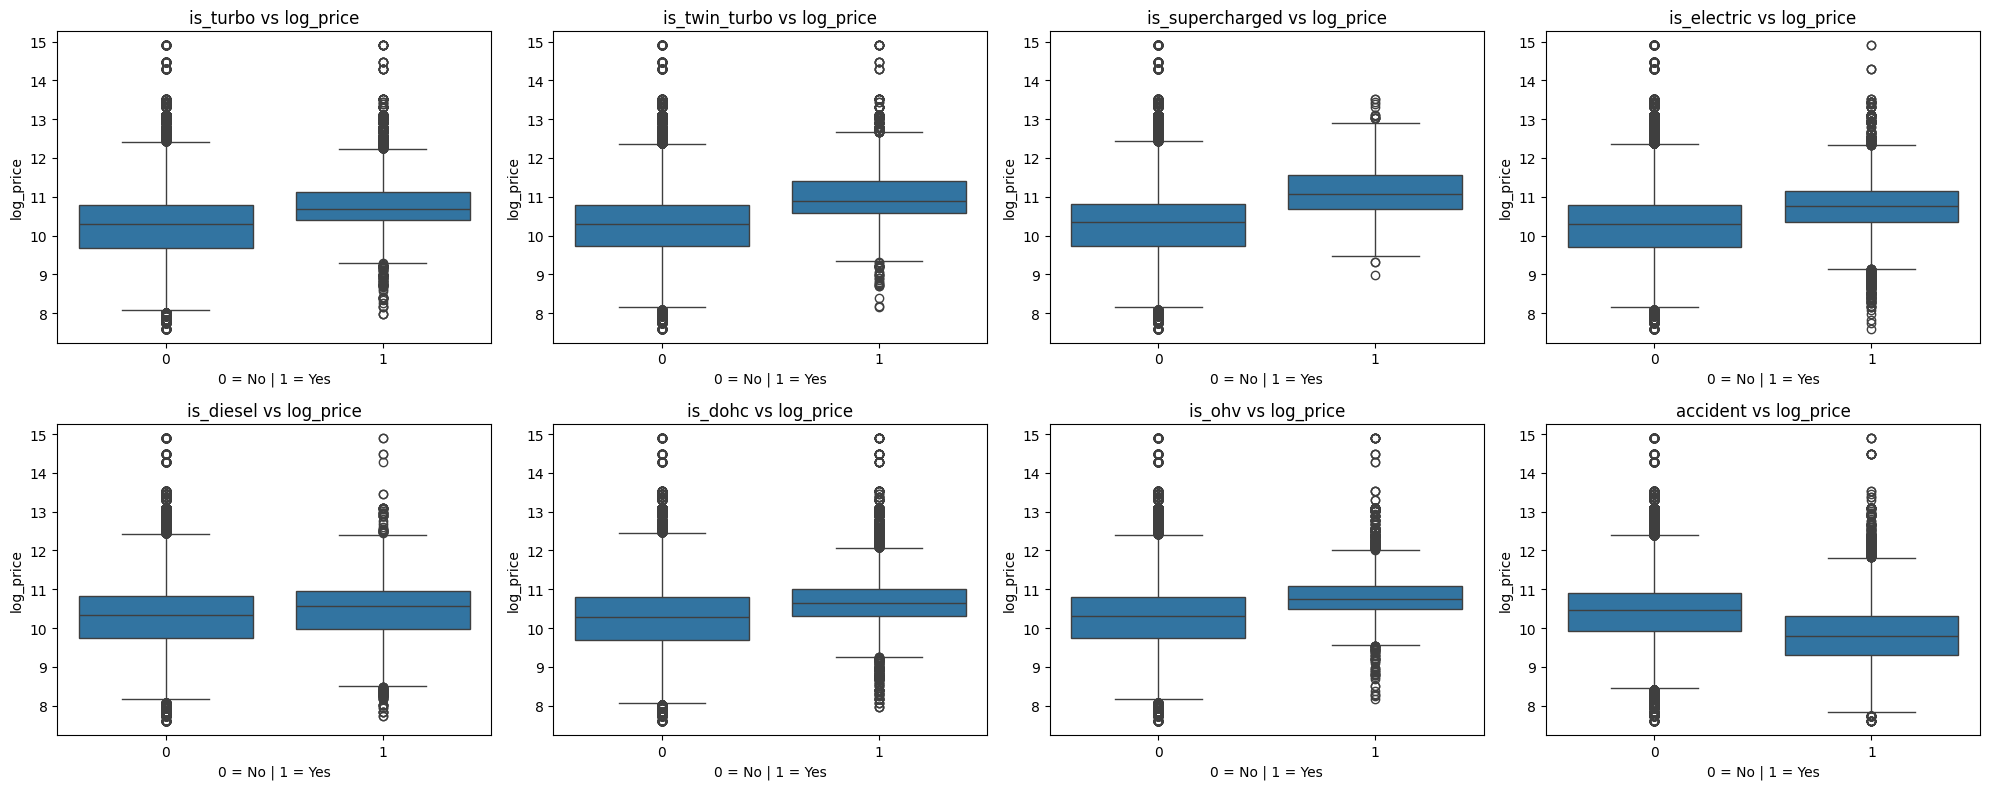

In [22]:
binary_cols = ['is_turbo', 'is_twin_turbo', 'is_supercharged',
               'is_electric', 'is_diesel', 'is_dohc', 'is_ohv', 'accident']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), binary_cols):
    sns.boxplot(x=df[col], y=df['log_price'], ax=ax)
    ax.set_title(f'{col} vs log_price')
    ax.set_xlabel('0 = No | 1 = Yes')
plt.tight_layout()
plt.show()

## 7. Preprocessing & Encoding

### 7.1 Ordinal Encoding — car_era

In [23]:
era_order = {'Classic': 0, 'Old': 1, 'Mid': 2, 'Recent': 3, 'Modern': 4}
df['car_era'] = df['car_era'].map(era_order)

### 7.2 One-Hot Encoding

In [24]:
df = pd.get_dummies(df, columns=['fuel_type', 'transmission', 'ext_col', 'int_col'], drop_first=True)

### 7.3 Train/Test Split

In [25]:
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test  = X_test.copy()

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')

Train size : (148417, 95)
Test size  : (37105, 95)


### 7.4 Target Encoding — brand & model

In [26]:
train_df = X_train.copy()
train_df['log_price'] = y_train

for col in ['brand', 'model']:
    mean_enc    = train_df.groupby(col)['log_price'].mean()
    global_mean = y_train.mean()
    X_train[col] = X_train[col].map(mean_enc)
    X_test[col]  = X_test[col].map(mean_enc).fillna(global_mean)

### 7.5 Scaling — Linear Models Only

In [27]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 8. Model Training & Comparison

In [28]:
results = {}


linear_models = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Lasso'            : Lasso(alpha=0.01),
}
for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'R2' : round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4)
    }

tree_models = {
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost'          : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=6, random_state=42, n_jobs=-1),
}
for name, model in tree_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R2' : round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4)
    }

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

                       R2     MAE     MSE
XGBoost            0.6544  0.3488  0.2486
Gradient Boosting  0.6470  0.3537  0.2540
Random Forest      0.6346  0.3611  0.2629
Linear Regression  0.6171  0.3720  0.2755
Ridge              0.6171  0.3720  0.2755
Lasso              0.6058  0.3782  0.2836


## 9. Model Evaluation

### 9.1 Model Comparison Chart

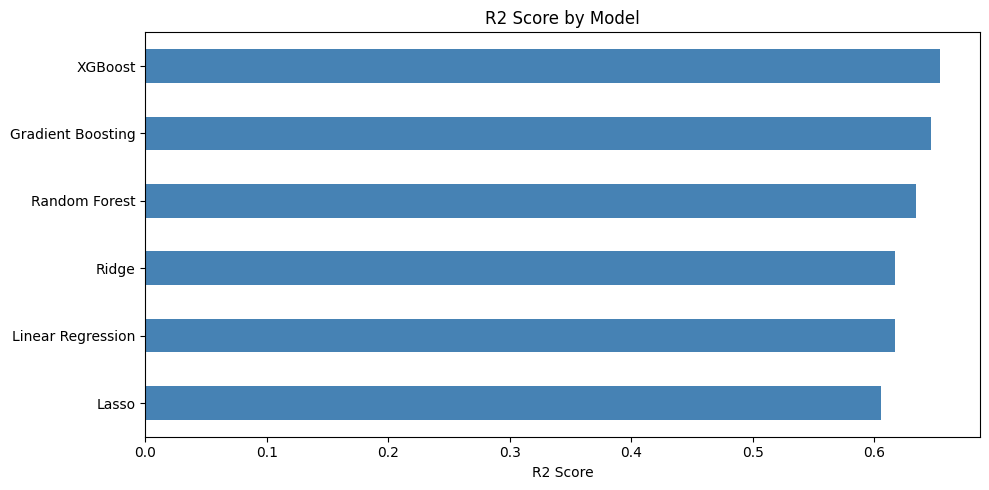

In [29]:
results_df['R2'].sort_values().plot(
    kind='barh', figsize=(10, 5), color='steelblue', title='R2 Score by Model'
)
plt.xlabel('R2 Score')
plt.tight_layout()
plt.show()

### 9.2 Actual vs Predicted & Residuals

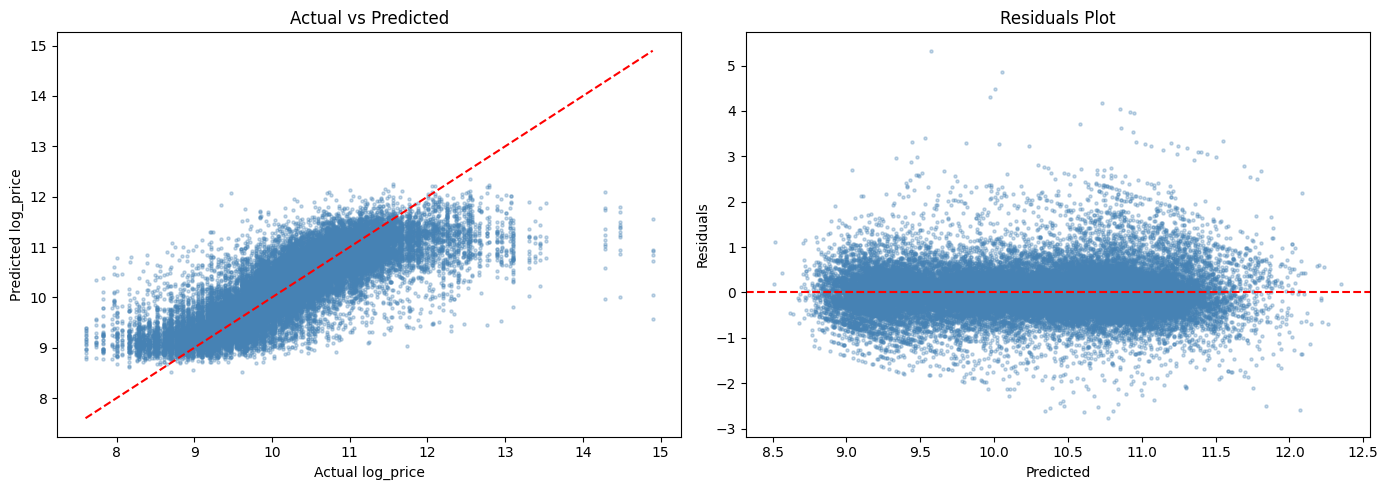

In [30]:
best_model = tree_models['XGBoost']
y_pred     = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual log_price')
axes[0].set_ylabel('Predicted log_price')
axes[0].set_title('Actual vs Predicted')


residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

### 9.3 Feature Importance

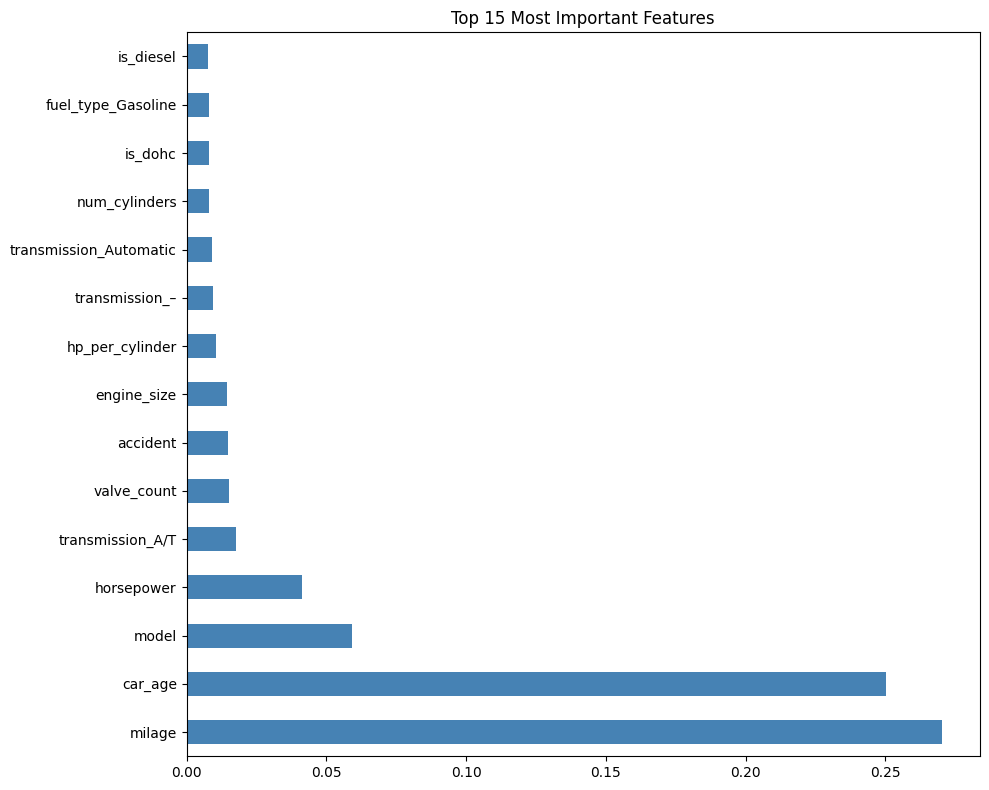

In [31]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10, 8))
feat_imp.nlargest(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

## 10. Final Results

In [34]:
best_r2  = r2_score(y_test, y_pred)
best_mae = mean_absolute_error(y_test, y_pred)
best_mse = mean_squared_error(y_test, y_pred)

print('=' * 45)
print(f'  Best Model  :  XGBoost')
print(f'  R2 Score    :  {best_r2:.4f}')
print(f'  MAE (log)   :  {best_mae:.4f}')
print(f'  MSE (log)   :  {best_mse:.4f}')
print('=' * 45)


  Best Model  :  XGBoost
  R2 Score    :  0.6544
  MAE (log)   :  0.3488
  MSE (log)   :  0.2486
